## Project 3: Matrix Factorization via Singular Value Decomposition (SVD)

**Course:** DATA 612 – Recommender Systems<br>
**Student:** Inna Yedzinovich


In this homework, I am going to extend the recommender system developed in homework 2 homework by applying matrix factorization techniques.

I want to use the same similarity-based methods:

 - User–User Collaborative Filtering
 - Content-Based Filtering

But then extend the system using Matrix Factorization via Singular Value Decomposition (SVD), which captures latent features in the data.

The dataset used in this project is the MovieLens dataset, available at:
- https://grouplens.org/datasets/movielens/ml_belief_2024/

At its core, Singular Value Decomposition (SVD) can be thought of as a way to simplify and summarize a large dataset. In a recommender system, I am going to start with a user–item matrix, where rows represent users, columns represent movies, and values represent ratings. This matrix is often large and sparse, making it difficult to directly analyze.
SVD decomposes this complex matrix into three smaller matrices that capture the underlying structure of the data. Instead of working with individual ratings, SVD identifies hidden patterns, or latent factors, such as user preferences and item characteristics.
Intuitively, SVD acts like a data “compressor” or “information distiller.” It reduces the original matrix into a smaller set of components that still preserve the most important relationships in the data. These components can be thought of as abstract features, such as preference for certain types of movies, even though they are not explicitly labeled.
This decomposition allows the system to reconstruct the original matrix and estimate missing values, enabling more accurate predictions compared to methods that rely only on direct similarity.

  - U → Users: represents users in terms of latent features, each row = user profile
  - Σ (Sigma) → Importance: weights of each latent factor, tells how important each pattern is
  - Vᵀ → Items: represents movies in same feature space, each column = movie profile

In simple words: 
  - U → Who the users are
  - V → What the movies are like
  - Σ → How important each pattern is
a 
This project focuses on the practical application of SVD using existing libraries. The goal is to understand how matrix factorization improves recommendation performance rather than deriving the underlying math.

Data Preparation (based ob homework 2):

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse.linalg import svds


In [2]:
ratings = pd.read_csv("data/user_rating_history.csv")
movies = pd.read_csv("data/movies.csv")

user_counts = ratings['userId'].value_counts()
active_users = user_counts[user_counts >= 50].index[:100]

subset = ratings[ratings['userId'].isin(active_users)]

# increasing matric to select 100 movies instead of 50 as in hw-2
movie_counts = subset['movieId'].value_counts()
popular_movies = movie_counts[movie_counts >= 50].index[:100]

subset = subset[subset['movieId'].isin(popular_movies)]

matrix = subset.pivot_table(
    index='userId',
    columns='movieId',
    values='rating',
    aggfunc='mean'
)

print(matrix.shape)

# adding movies names for visiability for later
movie_titles = movies.set_index('movieId')['title'].to_dict()
matrix_named = matrix.rename(columns=movie_titles)


(100, 100)


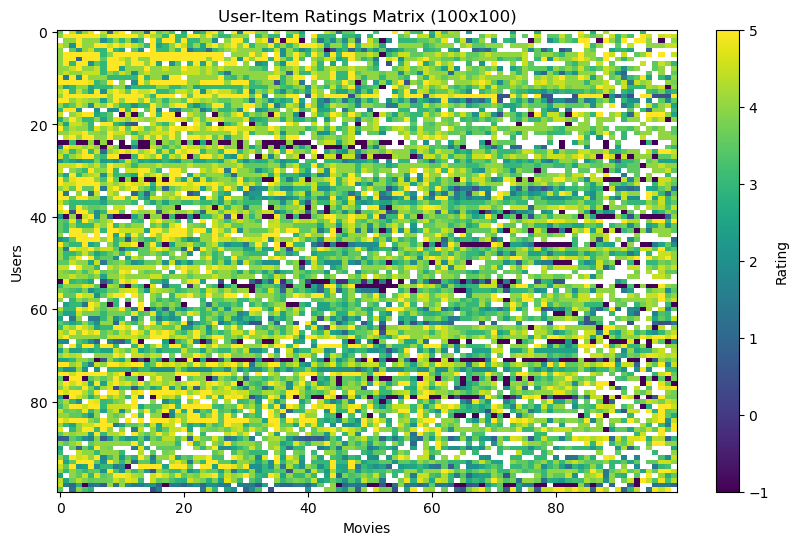

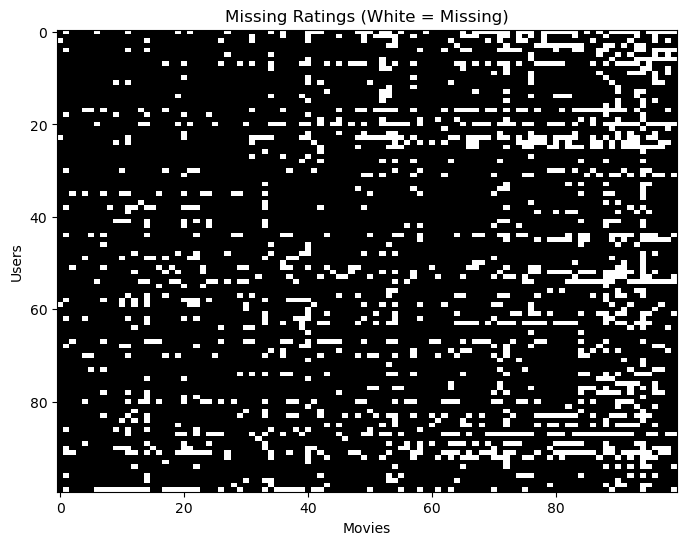

In [3]:
# heatmap to visualize the matrix
# rows: users, columns: movies, colors: ratings

#1
# “will THIS user like THAT movie?” - question for a heatmap

plt.figure(figsize=(10, 6))
plt.imshow(matrix, aspect='auto', cmap='viridis')
plt.title("User-Item Ratings Matrix (100x100)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.colorbar(label="Rating")
plt.show()

#2
# "how many missing values there are?"

plt.figure(figsize=(8,6))
plt.imshow(matrix.isna(), aspect='auto', cmap='gray')
plt.title("Missing Ratings (White = Missing)")
plt.xlabel("Movies")
plt.ylabel("Users")

plt.show()

The visualization reveals that the user–item matrix is highly sparse, meaning that most users have rated only a small subset of available movies. The white areas in the heatmap represent missing values, where no ratings exist. This sparsity highlights the need for recommendation algorithms, as the primary goal is to accurately estimate these missing ratings.

### Correction of Methodology
In the previous homework, the train/test split was applied after normalization and model construction. This approach introduced data leakage, as the model used information from the entire dataset, including values later used for evaluation.

In this assignment, the process has been corrected by applying the train/test split immediately after constructing the user–item matrix. 

All subsequent steps, including normalization, similarity computation, and prediction, are performed using only the training data. This ensures that the model is evaluated on truly unseen data and provides a more accurate measure of performance.

The plan: 

matrix
   ↓
visualizations(use matrix)
   ↓
train/test split
   ↓
train → mean-centering
     → similarity
     → prediction
   ↓
test → evaluation

In [4]:
#train/test
np.random.seed(66)

train = matrix.copy()
test = matrix.copy()

# mask of known ratings
mask = ~matrix.isna()

# randomly hide 20%
random_mask = np.random.rand(*matrix.shape) < 0.2

# keep only test values in test matrix
test[~(mask & random_mask)] = np.nan

# remove those values from train
train[mask & random_mask] = np.nan

print("Train size:", train.count().sum())
print("Test size:", test.count().sum())

Train size: 6833
Test size: 1724


### Mean-Centering
In this step, we normalize the user-item matrix by subtracting each user’s average rating from their individual ratings. This process, known as mean-centering, removes user-specific bias and allows the model to focus on relative preferences instead of absolute rating values.

After normalization, missing values are filled with zero, which represents no deviation from the user’s average rating. (Filling missing values with zero after mean-centering ensures that missing entries represent “no signal” rather than actual ratings.)

The visualization shows how ratings shift around zero, where positive values indicate above-average preferences and negative values indicate below-average preferences.average/neutral

What this visualization shows: 
- red: user liked movie MORE than their average
- blue: user liked it LESS than their average
- white: average / neutral

movieId    47        111       260       296       318       356       541     \
userId                                                                          
55083         NaN       NaN  0.951225 -1.048775       NaN  1.201225       NaN   
56787         NaN  0.980469  0.980469  0.980469  0.980469       NaN  0.980469   
59059         NaN  0.603680  0.603680  1.603680  0.603680  0.603680  0.603680   
74946         NaN -0.015152 -2.015152  0.984848 -0.015152 -0.015152       NaN   
75270    1.221154       NaN  0.721154 -0.778846  1.221154  1.721154       NaN   

movieId    586       593       608     ...    179401    179819    182715  \
userId                                 ...                                 
55083    0.951225 -2.548775  0.951225  ...       NaN       NaN       NaN   
56787   -0.019531  0.980469       NaN  ... -1.019531 -0.019531 -0.769531   
59059   -1.396320 -0.396320  0.603680  ... -0.396320  1.603680       NaN   
74946    0.984848  0.484848  0.984848  ... -0.515152

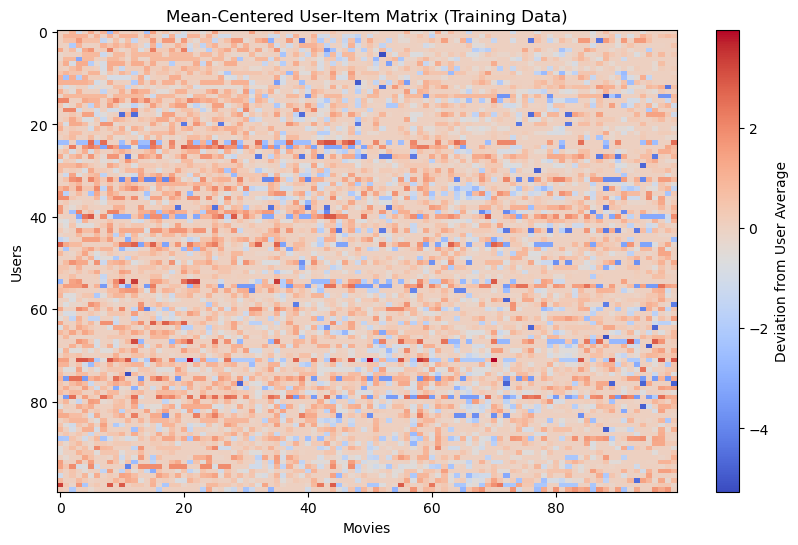

In [5]:
# Mean-Centering (ON TRAIN DATA ONLY)
# compute user average ratings (from TRAIN)
user_means = train.mean(axis=1)

# subtract mean
matrix_centered = train.sub(user_means, axis=0)

# fill missing values AFTER centering
matrix_centered_filled = matrix_centered.fillna(0)
print(matrix_centered.head())

# visual 
plt.figure(figsize=(10, 6))
plt.imshow(matrix_centered_filled, aspect='auto', cmap='coolwarm')
plt.title("Mean-Centered User-Item Matrix (Training Data)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.colorbar(label="Deviation from User Average")

plt.show()



### User Similarity & Prediction
Now that the data has been normalized using mean-centering, we compute how similar users are based on their rating patterns.
These similarities are then used to generate predictions by estimating unknown ratings as a weighted combination of ratings from similar users.

Original matrix:
       Movie A  Movie B
User1        5      NaN
User2        4      3.0
User3        1      2.0

User Means:
User1    5.0
User2    3.5
User3    1.5
dtype: float64

R Centered:
       Movie A  Movie B
User1      0.0      NaN
User2      0.5     -0.5
User3     -0.5      0.5

R Centered Filled:
       Movie A  Movie B
User1      0.0      0.0
User2      0.5     -0.5
User3     -0.5      0.5

Similarity (with diagonal = 1):
       User1  User2  User3
User1    0.0    0.0    0.0
User2    0.0    1.0   -1.0
User3    0.0   -1.0    1.0


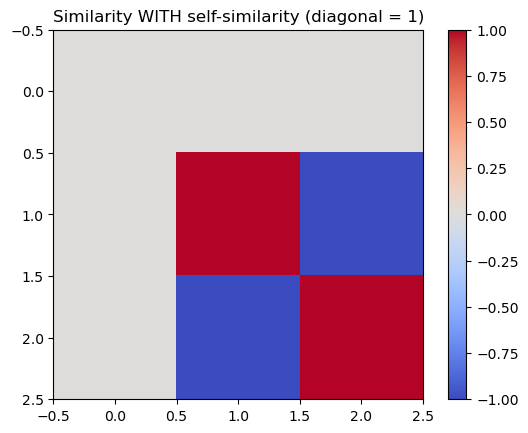


Similarity (diagonal removed):
       User1  User2  User3
User1    0.0    0.0    0.0
User2    0.0    0.0   -1.0
User3    0.0   -1.0    0.0


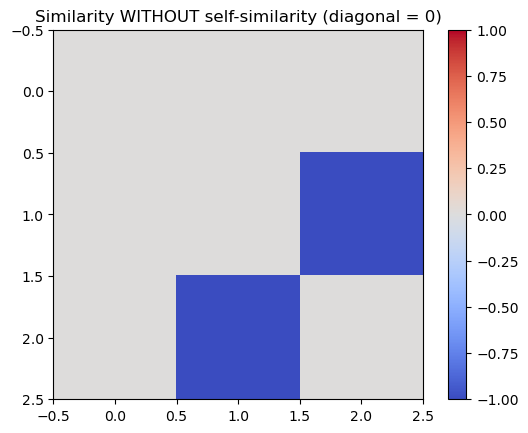

In [6]:
# Note 1: to visualize the concept of clearing the diagonal 

# small example matrix
# rows = users, columns = movies
R = pd.DataFrame({
    "Movie A": [5, 4, 1],
    "Movie B": [np.nan, 3, 2]
}, index=["User1", "User2", "User3"])

print("Original matrix:")
print(R)

user_means_test = R.mean(axis=1)
print("\nUser Means:")
print(user_means_test)

R_centered = R.sub(user_means_test, axis=0)
print("\nR Centered:")
print(R_centered)

R_centered_filled = R_centered.fillna(0)
print("\nR Centered Filled:")
print(R_centered_filled)

sim = cosine_similarity(R_centered_filled)
sim_df = pd.DataFrame(sim, index=R.index, columns=R.index)

# not fixed diagonal
print("\nSimilarity (with diagonal = 1):")
print(sim_df)

plt.imshow(sim_df, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Similarity WITH self-similarity (diagonal = 1)")
plt.colorbar()
plt.show()


# fix diagonal 
np.fill_diagonal(sim_df.values, 0)

print("\nSimilarity (diagonal removed):")
print(sim_df)

plt.imshow(sim_df, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Similarity WITHOUT self-similarity (diagonal = 0)")
plt.colorbar()
plt.show()


User similarity matrix:
userId    55083     56787     59059     74946     75270     90926     101362  \
userId                                                                         
55083   0.000000 -0.129025  0.010530  0.082543  0.004263  0.097958  0.200051   
56787  -0.129025  0.000000  0.143154  0.119089  0.020164  0.138580  0.044925   
59059   0.010530  0.143154  0.000000 -0.066819  0.153846  0.086720  0.147646   
74946   0.082543  0.119089 -0.066819  0.000000  0.121857  0.198044 -0.074055   
75270   0.004263  0.020164  0.153846  0.121857  0.000000  0.140694  0.177227   

userId    101545    101563    102175  ...    371191    378530    380017  \
userId                                ...                                 
55083  -0.085752 -0.126844 -0.055719  ...  0.113893 -0.052431  0.070598   
56787   0.225052  0.106926  0.175004  ...  0.249933  0.070576  0.139143   
59059   0.082632  0.171173  0.000854  ...  0.007317  0.022035  0.130098   
74946   0.257067 -0.095137  0.039454  ..

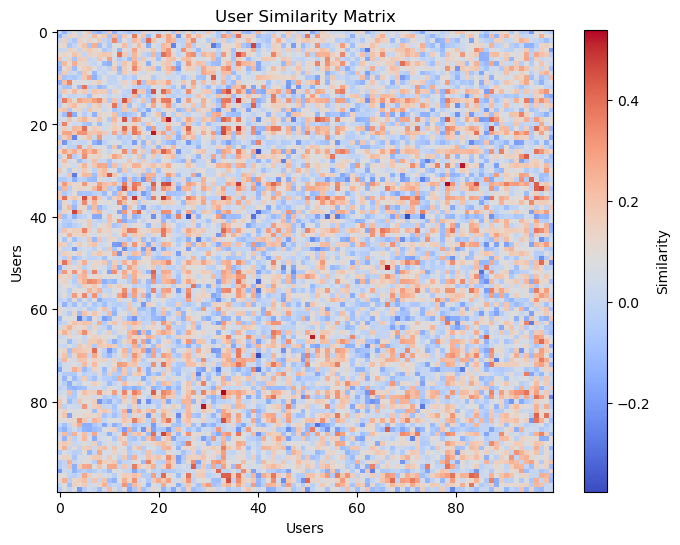

In [7]:
# compute similarity using mean-centered TRAIN data
user_similarity = cosine_similarity(matrix_centered_filled)

# convert to DataFrame (for readability)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train.index,
    columns=train.index
)

# Replace NaNs in similarity matrix with 0
user_similarity_df = user_similarity_df.fillna(0)

# missed in prev homework, "For each user, remove their similarity with themselves” - that is why it is needed. 
# The diagonal of the similarity matrix is set to zero to remove self-similarity, 
#ensuring that predictions are based only on other users and not influenced by the user’s own ratings.
# see note 1 for proof. 

np.fill_diagonal(user_similarity_df.values, 0)

print("User similarity matrix:")
print(user_similarity_df.head())

# visual  
plt.figure(figsize=(8, 6))
plt.imshow(user_similarity_df, aspect='auto', cmap='coolwarm')

plt.title("User Similarity Matrix")
plt.xlabel("Users")
plt.ylabel("Users")

plt.colorbar(label="Similarity")

plt.show()

Predicted ratings:
movieId    47        111       260       296       318       356       541     \
userId                                                                          
55083    3.518411  3.360639  3.806058  3.247959  3.758810  3.764123  3.725354   
56787    4.459741  4.545300  4.236447  4.600098  4.461773  3.970192  4.317273   
59059    3.648883  3.512408  3.717905  3.803054  3.719489  3.757409  3.492609   
74946    4.394922  4.293381  3.705726  4.458193  4.075592  3.731586  4.065269   
75270    3.132092  3.037600  3.127300  3.183694  3.127599  3.116268  2.952268   

movieId    586       593       608     ...    179401    179819    182715  \
userId                                 ...                                 
55083    3.675759  3.447732  3.605836  ...  3.491353  3.368762  3.657040   
56787    3.721481  4.519644  4.462025  ...  3.461821  3.784698  3.863487   
59059    3.137755  3.820067  3.702888  ...  3.055680  3.293400  3.203665   
74946    3.977024  4.316613  4.32

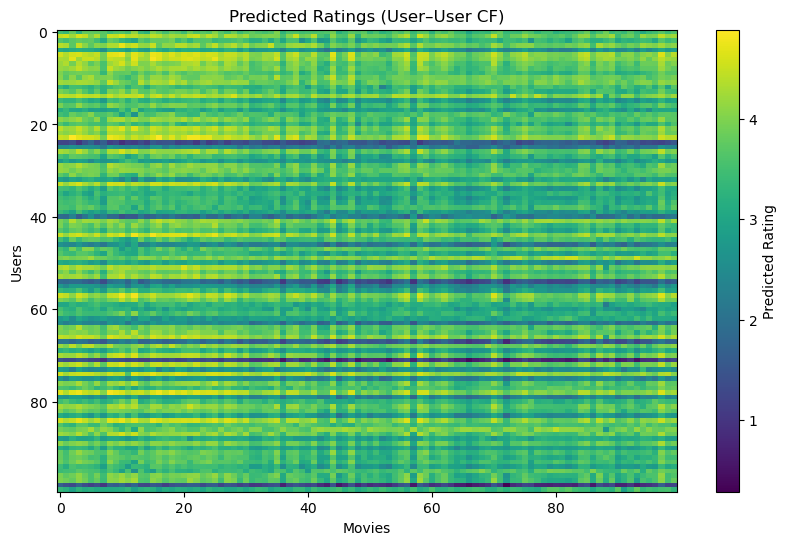

In [8]:
# Prediction (User–User CF)

# similarity (from TRAIN)
user_similarity = cosine_similarity(matrix_centered_filled)
np.fill_diagonal(user_similarity, 0)

# prediction (vectorized)
predicted_centered = user_similarity.dot(matrix_centered_filled) / \
                     np.abs(user_similarity).sum(axis=1).reshape(-1, 1)

# add mean back
predicted_user = predicted_centered + user_means.values.reshape(-1, 1)

# convert to DataFrame
predicted_user = pd.DataFrame(
    predicted_user,
    index=train.index,
    columns=train.columns
)
print("Predicted ratings:")
print(predicted_user.head())

# visual
plt.figure(figsize=(10, 6))
plt.imshow(predicted_user, aspect='auto', cmap='viridis')

plt.title("Predicted Ratings (User–User CF)")
plt.xlabel("Movies")
plt.ylabel("Users")

plt.colorbar(label="Predicted Rating")

plt.show()

### Evaluation (RMSE + MAE)


In [9]:
# Evaluation (User–User CF)

# mask → where test has real values
mask = ~test.isna()

# extract true ratings
y_true = test.values[mask.values]

# extract predicted ratings
y_pred = predicted_user.values[mask.values]

# compute RMSE
rmse_user = np.sqrt(mean_squared_error(y_true, y_pred))

# compute MAE
mae_user = mean_absolute_error(y_true, y_pred)

print("User–User CF Results:")
print("RMSE:", rmse_user)
print("MAE:", mae_user)

User–User CF Results:
RMSE: 1.206563572730515
MAE: 0.8667714256639809


The model is fairly accurate, with predictions typically within about 1 rating point of the actual value. This shows the model captures general user preferences, but it is not perfect.

### Content-Based Filtering
In the content-based approach, movies are represented using their genres. Each movie is converted into a vector using a bag-of-words representation, and cosine similarity is used to compute similarity between movies.

Predictions are generated by taking a weighted combination of movies that a user has already rated, where weights correspond to movie similarity.

The model is evaluated using RMSE and MAE on the test dataset.

Movie similarity:
movieId    47        111     260       296       318       356       541     \
movieId                                                                       
47       1.000000  0.408248     0.0  0.353553  0.000000  0.000000  0.353553   
111      0.408248  1.000000     0.0  0.866025  0.816497  0.288675  0.288675   
260      0.000000  0.000000     1.0  0.000000  0.000000  0.000000  0.750000   
296      0.353553  0.866025     0.0  1.000000  0.707107  0.500000  0.250000   
318      0.000000  0.816497     0.0  0.707107  1.000000  0.353553  0.000000   

movieId    586       593       608     ...   179401    179819    182715  \
movieId                                ...                                
47       0.000000  0.408248  0.353553  ...  0.00000  0.000000  0.632456   
111      0.000000  0.666667  0.866025  ...  0.00000  0.000000  0.258199   
260      0.000000  0.000000  0.000000  ...  0.57735  0.894427  0.670820   
296      0.353553  0.577350  1.000000  ...  0.00000  

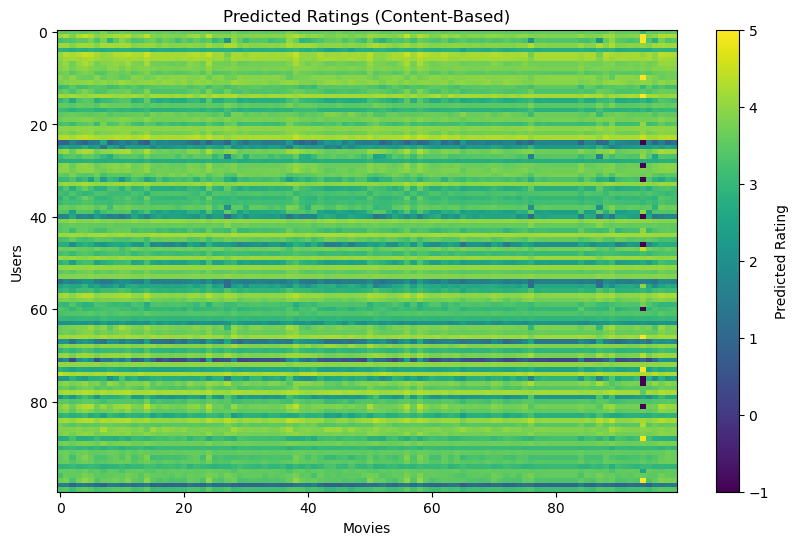

Content-Based Results:
RMSE: 1.2464146350931467
MAE: 0.908601594256477


In [10]:
# Content-Based Filtering

# keep only movies in our matrix
movies_small = movies[movies['movieId'].isin(matrix.columns)].copy()

# clean genres
movies_small['genres_clean'] = movies_small['genres'].str.replace('|', ' ', regex=False)

# vectorize genres
vectorizer = CountVectorizer()
genre_matrix = vectorizer.fit_transform(movies_small['genres_clean'])

# movie similarity
movie_similarity = cosine_similarity(genre_matrix)

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movies_small['movieId'],
    columns=movies_small['movieId']
)

print("Movie similarity:")
print(movie_similarity_df.head())


# prediction (TRAIN only)

# make sure TRAIN columns match movie similarity
train_cb = train[movie_similarity_df.columns]

# fill missing ratings: missing values ≈ user’s average rating, not missing = 0 for content-based

# In user-based collaborative filtering, missing values are set to zero after mean-centering, 
# where zero represents no deviation from a user’s average. 
# In contrast, content-based filtering operates on raw ratings, where zero would incorrectly imply a negative rating, 
# so missing values are replaced with the user’s average rating instead.

train_cb_filled = train_cb.apply(lambda row: row.fillna(row.mean()), axis=1)

# prediction formula
predicted_cb = train_cb_filled.dot(movie_similarity_df) / \
               np.abs(movie_similarity_df).sum(axis=1).values.reshape(1, -1)

# convert to DataFrame
predicted_cb = pd.DataFrame(
    predicted_cb,
    index=train.index,
    columns=train_cb.columns
)

print("Content-Based predictions:")
print(predicted_cb.head())


# visual

plt.figure(figsize=(10, 6))
plt.imshow(predicted_cb, aspect='auto', cmap='viridis')

plt.title("Predicted Ratings (Content-Based)")
plt.xlabel("Movies")
plt.ylabel("Users")

plt.colorbar(label="Predicted Rating")
plt.show()


# evaluation (TEST only)

# mask for test values
mask = ~test.isna()

# align predictions with test (same columns!)
predicted_cb = predicted_cb[test.columns]

# extract values
y_true_cb = test.values[mask.values]
y_pred_cb = predicted_cb.values[mask.values]

# metrics
rmse_cb = np.sqrt(mean_squared_error(y_true_cb, y_pred_cb))
mae_cb = mean_absolute_error(y_true_cb, y_pred_cb)

print("Content-Based Results:")
print("RMSE:", rmse_cb)
print("MAE:", mae_cb)

The Content-Based model is less accurate, with predictions typically deviating by around 1.5 rating points from the actual values. This suggests that while the model captures some general patterns based on movie features, it struggles to represent user preferences precisely. The higher error indicates that using only genres provides limited information, leading to less reliable recommendations compared to collaborative methods.

### Singular Value Decomposition (SVD)

Core Idea: Instead of comparing users or using genres, SVD learns hidden patterns in the data. 

[(1, np.float64(1.2202935509010264)), (3, np.float64(1.203396094079565)), (5, np.float64(1.1996110293119189)), (10, np.float64(1.2159302350657963)), (20, np.float64(1.2416748020542387)), (30, np.float64(1.2561904303389098))]
[[21.3798108   0.          0.          0.          0.        ]
 [ 0.         22.55278217  0.          0.          0.        ]
 [ 0.          0.         23.39459826  0.          0.        ]
 [ 0.          0.          0.         27.87430249  0.        ]
 [ 0.          0.          0.          0.         36.11470748]]
SVD predictions:
movieId    47        111       260       296       318       356       541     \
userId                                                                          
55083    3.405456  3.323426  3.752213  3.309360  3.588573  3.719752  3.502124   
56787    4.458953  4.467265  4.003658  4.614424  4.353580  4.113840  4.026809   
59059    4.142257  4.140642  3.417377  4.558107  3.971295  3.792828  3.545608   
74946    4.215038  4.308120  3.841456

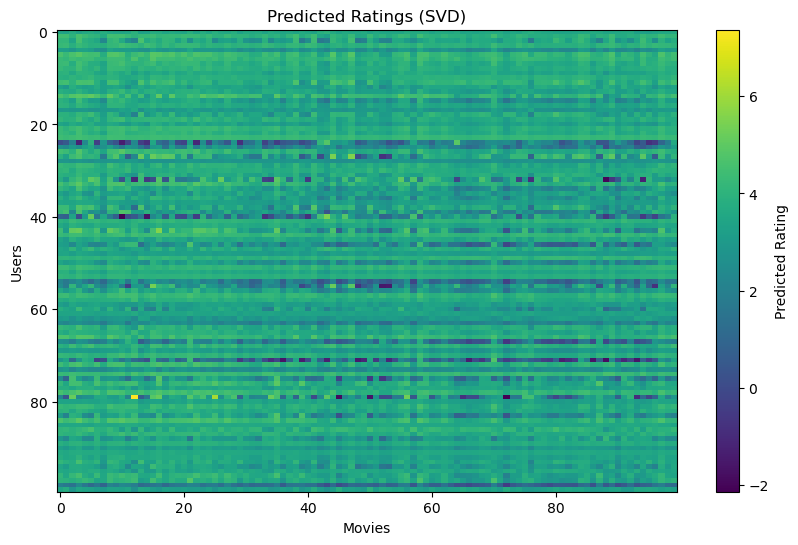

In [11]:
# SVD needs a complete numeric matrix, mean-centered TRAIN matrix is used here
user_means = train.mean(axis=1)
matrix_centered = train.sub(user_means, axis=0)

# fill missing values
matrix_svd = matrix_centered.fillna(0)

#SDI 
# number of latent factors(no idea which one to use, let's try different first)

results = []
for k in [1, 3, 5, 10, 20, 30]:
    U, sigma, Vt = svds(matrix_svd.values, k=k)
    sigma = np.diag(sigma)

    pred = np.dot(np.dot(U, sigma), Vt) + user_means.values.reshape(-1, 1)

    mask = ~test.isna()
    y_true = test.values[mask.values]
    y_pred = pred[mask.values]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    results.append((k, rmse))

print(results)

# k controls how much detail the model keeps. A moderate value (k = 5) is chosen to balance accuracy and overfitting (lowest RMSE).
k = 5
U, sigma, Vt = svds(matrix_svd.values, k=k)
sigma = np.diag(sigma)
print(sigma)

# reconstruct matrix
matrix_pred_svd = np.dot(np.dot(U, sigma), Vt)

# add user means back
matrix_pred_svd = matrix_pred_svd + user_means.values.reshape(-1, 1)

# prediction
predicted_svd = pd.DataFrame(
    matrix_pred_svd,
    index=train.index,
    columns=train.columns
)

print("SVD predictions:")
print(predicted_svd.head())

# svd rmse and mae
mask = ~test.isna()

y_true_svd = test.values[mask.values]
y_pred_svd = predicted_svd.values[mask.values]

rmse_svd = np.sqrt(mean_squared_error(y_true_svd, y_pred_svd))
mae_svd = mean_absolute_error(y_true_svd, y_pred_svd)

print("SVD Results:")
print("RMSE:", rmse_svd)
print("MAE:", mae_svd)

# visual
plt.figure(figsize=(10, 6))
plt.imshow(predicted_svd, aspect='auto', cmap='viridis')

plt.title("Predicted Ratings (SVD)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.colorbar(label="Predicted Rating")
plt.show()


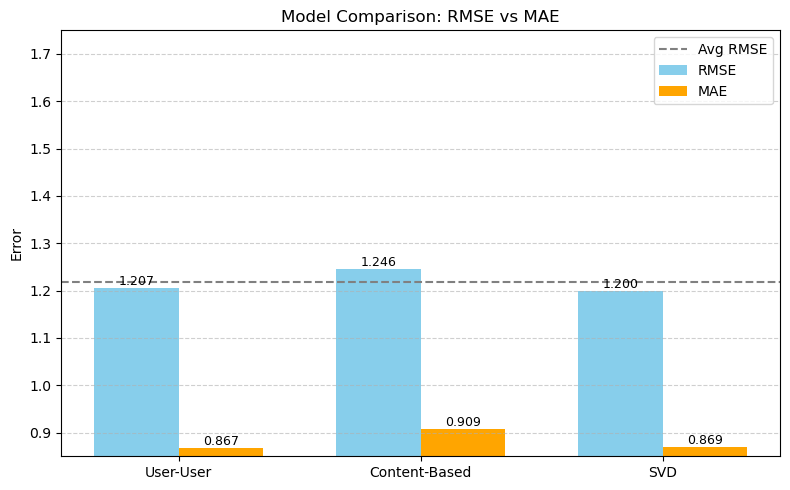

In [12]:
# all models visual comparison
import numpy as np
import matplotlib.pyplot as plt

models = ["User-User", "Content-Based", "SVD"]

rmse_values = [rmse_user, rmse_cb, rmse_svd]
mae_values = [mae_user, mae_cb, mae_svd]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width/2, rmse_values, width, label='RMSE', color='skyblue')
bars2 = plt.bar(x + width/2, mae_values, width, label='MAE', color='orange')

plt.xticks(x, models)
plt.ylabel("Error")
plt.title("Model Comparison: RMSE vs MAE")
plt.ylim(0.85, 1.75)

for bar in bars1:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.3f}", 
             ha='center', va='bottom', fontsize=9)

for bar in bars2:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.3f}", 
             ha='center', va='bottom', fontsize=9)

avg_rmse = np.mean(rmse_values)
plt.axhline(avg_rmse, color='gray', linestyle='--', linewidth=1.5, label='Avg RMSE')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()



## Summury: Models Comparison

The performance of three recommendation approaches—User–User Collaborative Filtering, Content-Based Filtering, and SVD—was evaluated using RMSE and MAE.

The results show that SVD with k=5k = 5k=5 achieved the lowest RMSE, indicating the most accurate predictions. User–User Collaborative Filtering produced similar performance, suggesting that user similarity provides a strong baseline for recommendation.

In contrast, the Content-Based model performed significantly worse, with much higher error values. This is due to its reliance on limited features (movie genres), which do not fully capture user preferences.

Overall, SVD provides the best performance by learning latent factors that represent hidden relationships between users and items. However, given the relatively small and sparse dataset, the improvement over User–User filtering is modest.